## Why?
- to transfer data
- No-Cloning Theorem: can't just copy a quantum state; will get collapsed doing so

## How?
- Take 2 entangled qubits (A1, A2)
- A third qubit has the info to send (B)
- A1 and B are entangled by one of the two persons
- A1, B both measured, that measurement (cbits) sent to person having A2
- todo


In [ ]:
!pip3 install -q qiskit qiskit-aer qiskit[visualization] pylatexenc pennylane pennylane-qiskit

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

### Defining qubits:
- 0: B
- 1: A1
- 2: A2

In [3]:
qc = QuantumCircuit(3, 3) #2 cbits for B, A1, A2

### Setting up B: (Eg: Minus state here, =1 as default is 0)

In [4]:
qc.x(0) #randomly applying some gate to make it secret interesting instead of 0
qc.h(0)

### Setting up A1 entangled with A2:

In [5]:
qc.h(1)
qc.cx(1, 2)
qc.barrier() #line sep in draw

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### Entangling A1 with B:

In [6]:
qc.cx(0, 1) #Checking flip (0/1)
qc.h(0) #Phase (+/-) checking with first qbit
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### Why qc.h(0) here?
- measure() cannot output the phase (sign) of qubit
- qc.h(0) converts the phase to another bit
- When measured:
  - 00: +, no flip
  - 01: +, flip
  - 10: -, no flip
  - 11: -, flip

### Measuring A1, B; sending the cbits to A2 over the internet (or however):

In [7]:
qc.measure(0, 0)
qc.measure(1, 1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### Reconstructing B (the message) by Person #2 using A2:

In [8]:
with qc.if_test((qc.clbits[1], 1)):
  qc.x(2)
with qc.if_test((qc.clbits[0], 1)):
  qc.z(2)

- z gate: phase change (+ to -, - to +)
- qc.f_test(X, Y): if cbitX has value Y
  - apply x gate (flip 1/0) if 1 at cbit1 (which stores flip)
  - apply z gate (flip +/-) if 1 at cbit0 (which stores phase)

In [9]:
print(qc.draw())

     ┌───┐┌───┐ ░      ┌───┐ ░ ┌─┐    ░                                      »
q_0: ┤ X ├┤ H ├─░───■──┤ H ├─░─┤M├────░──────────────────────────────────────»
     ├───┤└───┘ ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐ ░                                      »
q_1: ┤ H ├──■───░─┤ X ├──────░──╫─┤M├─░──────────────────────────────────────»
     └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘ ░   ┌──────  ┌───┐ ───────┐   ┌──────  »
q_2: ─────┤ X ├─░────────────░──╫──╫──░───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─»
          └───┘ ░            ░  ║  ║  ░   └──╥───  └───┘ ───────┘   └──╥───  »
                                ║  ║    ┌────╨────┐               ┌────╨────┐»
c: 3/═══════════════════════════╩══╩════╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞»
                                0  1    └─────────┘               └─────────┘»
«                    
«q_0: ───────────────
«                    
«q_1: ───────────────
«     ┌───┐ ───────┐ 
«q_2: ┤ Z ├  End-0 ├─
«     └───┘ ───────┘ 
«c: 3/═══════════════
«                    


### Verifying:
- if data of q0 is successfully moved to q2, then applying H gate and then measurng will give exact 1 [=q0] (cancel the superposition, meaning it's already in one)

In [10]:
qc.h(2)
qc.measure(2, 2)

{'101': 25022, '110': 24738, '111': 25139, '100': 25101}


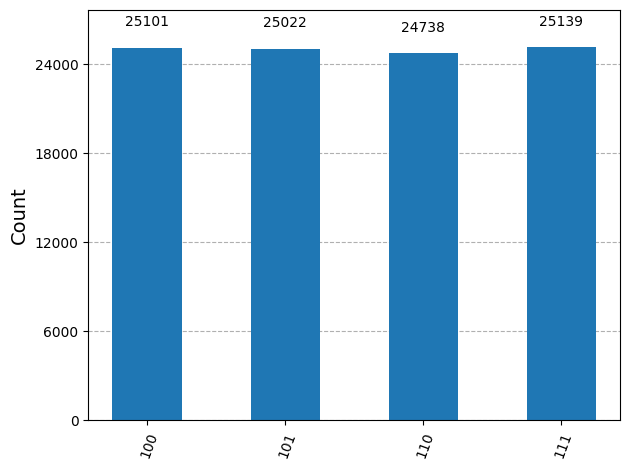

In [13]:
sim = AerSimulator()
job = sim.run(qc, shots=100000)
counts = job.result().get_counts()
print(counts)
plot_histogram(counts)

- Output dict has indices 100, 101, 110, 111
- Qiskit follows Little Endian Naming: "qbit2qbit1qbit0"
- Hence, qbit2 is ALWAYS 1
- qbit0, qbit1 are 0,1 as they had lost the values (now belongs to the relationship between both instead of individual qbits) they had before superposition, the moment they got entangled ["individually random, jointly meaningful"]
- Even though qbit1 lost the original message, it was still transmitted to qbit2

## Demonstrating how qbits lose their original value when they get entangled:


In [20]:
def entanglementTest():
  qc = QuantumCircuit(2) #not creating clbits; will use measure_all
  #q1 has value 0 (default)
  qc.x(1)
  #q1 has value 1

  #Putting in superposition:
  qc.h(0)
  # qc.h(1) :X No,
  # if both in superposition, cnot doesnt create superposition,
  # effectively doing nothing, so either one needs to be definite

  #Entangling them:
  qc.cx(0, 1)

  #Un-applying superposition
  qc.h(0)
  qc.h(1)
  #Collapsing both:
  qc.measure_all()

  sim = AerSimulator()
  job = sim.run(qc, shots=1000)
  counts = job.result().get_counts()
  print(counts)
entanglementTest()



{'10': 499, '00': 501}


- If entangled: even after applying h gate again, output is 00, 11;
- qbits bound to be of same value